# Stock Price Prediction - Enhanced model

Add news to the price-only baseline

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

## 1. News sentiment extraction

I found two NLP approaches for news text:

- **VADER**: rule-based, fast, outputs a compund score plus sentiment labels.
- **FinBERT**: captures financial context, slower, outputs label plus confidence.


In [2]:
news_df = pd.read_csv('data/news.csv', parse_dates=['datetime'])
print(f"News articles: {len(news_df):,}")
news_df.head(3)

News articles: 4,440


,datetime,ticker,headline,summary
0,2024-10-29 18:07:48,AAPL,Apple Unveils the Redesigned Mac Mini,-- Apple overhauled the design of its Mac mini...
1,2024-10-29 02:21:10,AAPL,Apple blocked from selling iPhone 16 in Indone...,TECH giant Apple will not be allowed to sell i...
2,2024-10-28 14:05:22,AAPL,"Apple Rises on Apple Intelligence Rollout, New...",-- Apple unveiled its new iMac and said Apple ...


### 1.1 VADER

In [5]:
analyzer = SentimentIntensityAnalyzer()

def get_vader(text):
    if pd.isna(text): return {'compound': 0.0, 'pos': 0.0, 'neg': 0.0, 'neu': 1.0}
    return analyzer.polarity_scores(str(text))

vader_hl = news_df['headline'].apply(get_vader).apply(pd.Series)
vader_hl.columns = [f'vader_hl_{c}' for c in vader_hl.columns]
vader_sm = news_df['summary'].apply(get_vader).apply(pd.Series)
vader_sm.columns = [f'vader_sm_{c}' for c in vader_sm.columns]

news_df['vader_hl_compound'] = vader_hl['vader_hl_compound']
news_df['vader_sm_compound'] = vader_sm['vader_sm_compound']

print(f"VADER headline compound: mean={vader_hl['vader_hl_compound'].mean():.3f}, std={vader_hl['vader_hl_compound'].std():.3f}")

VADER headline compound: mean=0.088, std=0.312


### 1.2 FinBERT sentiment

FinBERT outputs positive/negative/neutral labels with confidence. We convert this into a signed score: `+confidence` for positive, `-confidence` for negative, `0` for neutral.

In [7]:
finbert = pipeline('sentiment-analysis', model='ProsusAI/finbert',
                    truncation=True, max_length=512, device=0, batch_size=32)

def score_finbert(texts):
    clean = [str(t) if pd.notna(t) else '' for t in texts]
    results = finbert(clean)
    scores = []
    for r in results:
        if r['label'] == 'positive':   scores.append(r['score'])
        elif r['label'] == 'negative': scores.append(-r['score'])
        else:                          scores.append(0.0)
    return scores

news_df['finbert_hl'] = score_finbert(news_df['headline'].tolist())
news_df['finbert_sm'] = score_finbert(news_df['summary'].tolist())

print(f"FinBERT headline: mean={news_df['finbert_hl'].mean():.3f}, std={news_df['finbert_hl'].std():.3f}")

Device set to use cuda:0


FinBERT headline: mean=-0.040, std=0.544


In [8]:
news_scored = news_df[['datetime', 'ticker', 'vader_hl_compound', 'vader_sm_compound', 'finbert_hl', 'finbert_sm']]
news_scored.head(3)

,datetime,ticker,vader_hl_compound,vader_sm_compound,finbert_hl,finbert_sm
0,2024-10-29 18:07:48,AAPL,0.0000,-0.1280,0.000000,-0.443744
1,2024-10-29 02:21:10,AAPL,-0.2732,0.0000,-0.951898,-0.702579
2,2024-10-28 14:05:22,AAPL,0.4767,0.4767,0.711824,0.000000


## 2. News feature aggregation

Map news to **trading dates** (weekends/after-hours → next trading day), then aggregate per ticker per day.

In [9]:
price_df = pd.read_csv('output/price_features.csv', parse_dates=['date'])
trading_dates = sorted(price_df['date'].unique())

news_scored['news_date'] = news_scored['datetime'].dt.normalize()
trading_cal = pd.DataFrame({'date': trading_dates})

news_sorted = news_scored.sort_values('news_date')
news_mapped = pd.merge_asof(
    news_sorted, trading_cal.rename(columns={'date': 'trading_date'}),
    left_on='news_date', right_on='trading_date', direction='forward'
).dropna(subset=['trading_date'])

print(f"Articles mapped: {len(news_mapped):,} / {len(news_scored):,}")

Articles mapped: 4,391 / 4,440


In [ ]:
sentiment_features = news_mapped.groupby(['trading_date', 'ticker']).agg(
    vader_hl_avg=('vader_hl_compound', 'mean'),
    vader_hl_max=('vader_hl_compound', 'max'),
    vader_hl_min=('vader_hl_compound', 'min'),
    vader_sm_avg=('vader_sm_compound', 'mean'),
    finbert_hl_avg=('finbert_hl', 'mean'),
    finbert_hl_max=('finbert_hl', 'max'),
    finbert_hl_min=('finbert_hl', 'min'),
    finbert_sm_avg=('finbert_sm', 'mean'),
    news_count=('finbert_hl', 'count')
).reset_index()

print(f"Sentiment features shape: {sentiment_features.shape}")

Sentiment features shape: (1176, 11)


## 3. Merge price + news features

In [11]:
combined_df = price_df.merge(
    sentiment_features, left_on=['date', 'ticker'],
    right_on=['trading_date', 'ticker'], how='left'
).drop(columns=['trading_date'], errors='ignore')

vader_cols = ['vader_hl_avg', 'vader_hl_max', 'vader_hl_min', 'vader_sm_avg']
finbert_cols = ['finbert_hl_avg', 'finbert_hl_max', 'finbert_hl_min', 'finbert_sm_avg']
shared_cols = ['news_count']
all_sent_cols = vader_cols + finbert_cols + shared_cols

combined_df[all_sent_cols] = combined_df[all_sent_cols].fillna(0)
print(f"Combined shape: {combined_df.shape}")

Combined shape: (1547, 33)


## 4. Train/Test split

Same chronological split (Aug 2024 cutoff) for all models.

In [12]:
exclude_cols = ['date', 'ticker', 'target', 'open', 'high', 'low', 'close', 'volume']
base_features = [c for c in combined_df.columns if c not in exclude_cols + all_sent_cols]
vader_features = base_features + vader_cols + shared_cols
finbert_features = base_features + finbert_cols + shared_cols
all_features = base_features + all_sent_cols

model_df = combined_df.dropna(subset=all_features + ['target']).copy()
split_date = pd.Timestamp('2024-08-01')
train_df = model_df[model_df['date'] < split_date]
test_df = model_df[model_df['date'] >= split_date]

print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")

Train rows: 1,120 | Test rows: 427


## 5. Comprehensive model matrix

Let's evaluate **Ridge**, **LightGBM** (see if it performs better than XGBoost), and **XGBoost** across four feature configurations:
1. **Price Only** (baseline)
2. **+ VADER** (lexicon sentiment)
3. **+ FinBERT** (transformer sentiment)
4. **+ Both** (full feature set)

In [22]:
def eval_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

def run_ridge(cols, name):
    sc = StandardScaler()
    X_tr = sc.fit_transform(train_df[cols])
    X_te = sc.transform(test_df[cols])
    m = Ridge(alpha=1.0).fit(X_tr, train_df['target'])
    p = m.predict(X_te)
    return m, p, eval_metrics(test_df['target'], p, name)

def run_lgb(cols, name):
    m = lgb.LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=-1)
    m.fit(train_df[cols].values, train_df['target'].values, eval_set=[(test_df[cols].values, test_df['target'].values)], callbacks=[lgb.early_stopping(50, verbose=False)])
    p = m.predict(test_df[cols].values)
    return m, p, eval_metrics(test_df['target'], p, name)

def run_xgb(cols, name):
    m = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42, early_stopping_rounds=50, verbosity=0)
    m.fit(train_df[cols].values, train_df['target'].values, eval_set=[(test_df[cols].values, test_df['target'].values)], verbose=False)
    p = m.predict(test_df[cols].values)
    return m, p, eval_metrics(test_df['target'], p, name)

# feature map
f_map = {'Price Only': base_features, '+ VADER': vader_features, '+ FinBERT': finbert_features, '+ Both': all_features}

results = []
models_dict = {}
preds_dict = {}

for cfg_name, cols in f_map.items():
    # Ridge
    r_m, r_p, r_res = run_ridge(cols, f'Ridge ({cfg_name})')
    results.append(r_res); models_dict[f'Ridge ({cfg_name})'] = (r_m, cols); preds_dict[f'Ridge ({cfg_name})'] = r_p
    
    # LightGBM
    l_m, l_p, l_res = run_lgb(cols, f'LightGBM ({cfg_name})')
    results.append(l_res); models_dict[f'LightGBM ({cfg_name})'] = (l_m, cols); preds_dict[f'LightGBM ({cfg_name})'] = l_p
    
    # XGBoost
    x_m, x_p, x_res = run_xgb(cols, f'XGBoost ({cfg_name})')
    results.append(x_res); models_dict[f'XGBoost ({cfg_name})'] = (x_m, cols); preds_dict[f'XGBoost ({cfg_name})'] = x_p
matrix_df = pd.DataFrame(results).set_index('model')
matrix_df.style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.2f}%', 'R2': '{:.4f}'})

,RMSE,MAE,MAPE,R2
model,,,,
Ridge (Price Only),6.3003,4.2625,1.85%,0.9981
LightGBM (Price Only),17.9830,9.0281,2.82%,0.9843
XGBoost (Price Only),19.8317,9.6293,2.97%,0.9810
Ridge (+ VADER),6.2978,4.2724,1.85%,0.9981
LightGBM (+ VADER),18.0380,8.8982,2.76%,0.9843
XGBoost (+ VADER),19.6677,9.5492,2.92%,0.9813
Ridge (+ FinBERT),6.3051,4.2930,1.86%,0.9981
LightGBM (+ FinBERT),18.0296,8.8556,2.74%,0.9843
XGBoost (+ FinBERT),19.3026,9.3704,2.88%,0.9820


### 5.1 Predicted vs actual (Ridge + VADER)

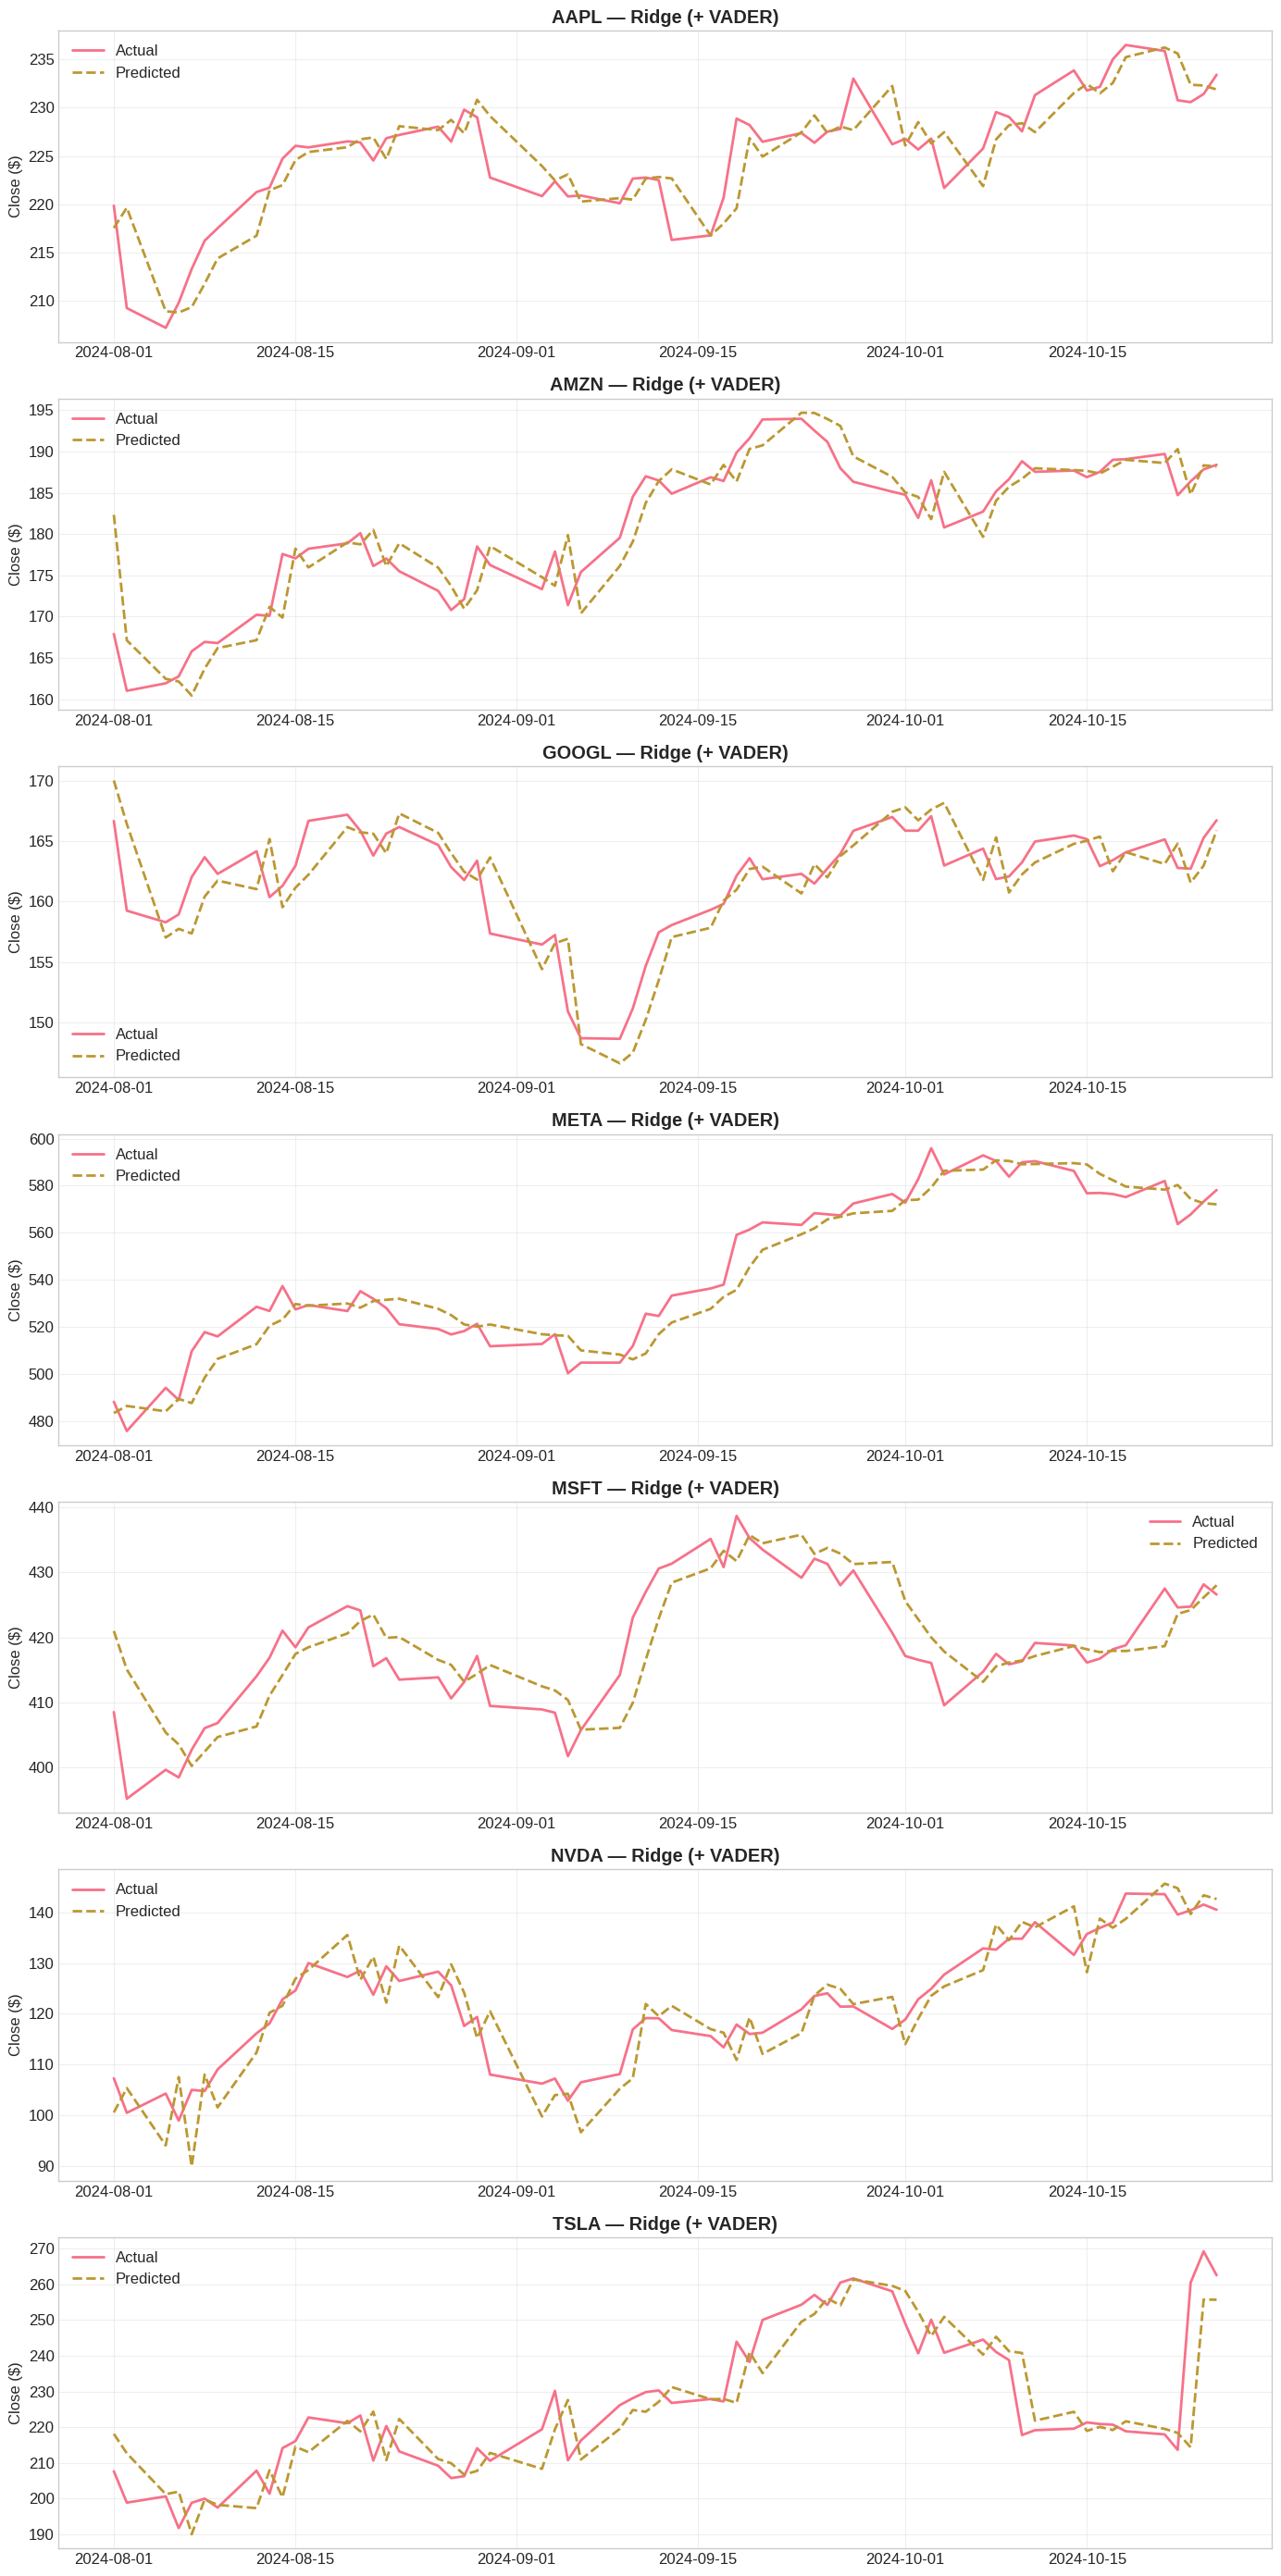

In [23]:
best_model_name = 'Ridge (+ VADER)'
best_pred = preds_dict[best_model_name]

test_plot = test_df[['date', 'ticker', 'target']].copy()
test_plot['predicted'] = best_pred
tickers = sorted(test_plot['ticker'].unique())

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))
for i, ticker in enumerate(tickers):
    t = test_plot[test_plot['ticker'] == ticker]
    axes[i].plot(t['date'], t['target'], label='Actual', linewidth=2)
    axes[i].plot(t['date'], t['predicted'], label='Predicted', linewidth=2, linestyle='--')
    axes[i].set_title(f'{ticker} — {best_model_name}', fontweight='bold')
    axes[i].set_ylabel('Close ($)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Per-ticker breakdown (Ridge + VADER)

In [24]:
per_ticker = []
for ticker in tickers:
    t = test_plot[test_plot['ticker'] == ticker]
    per_ticker.append({
        'ticker': ticker,
        'RMSE': np.sqrt(mean_squared_error(t['target'], t['predicted'])),
        'MAPE': np.mean(np.abs((t['target'] - t['predicted']) / t['target'])) * 100,
        'R2': r2_score(t['target'], t['predicted'])
    })
pd.DataFrame(per_ticker).set_index('ticker').style.format({'RMSE': '{:.4f}', 'MAPE': '{:.2f}%', 'R2': '{:.4f}'})

,RMSE,MAPE,R2
ticker,,,
AAPL,3.1753,1.03%,0.7393
AMZN,3.6884,1.51%,0.8111
GOOGL,2.5507,1.22%,0.6503
META,9.2259,1.34%,0.9175
MSFT,5.8463,1.05%,0.6429
NVDA,5.4713,3.79%,0.7811
TSLA,9.9100,3.02%,0.7383


### 5.3 Feature importance (LightGBM + Both)

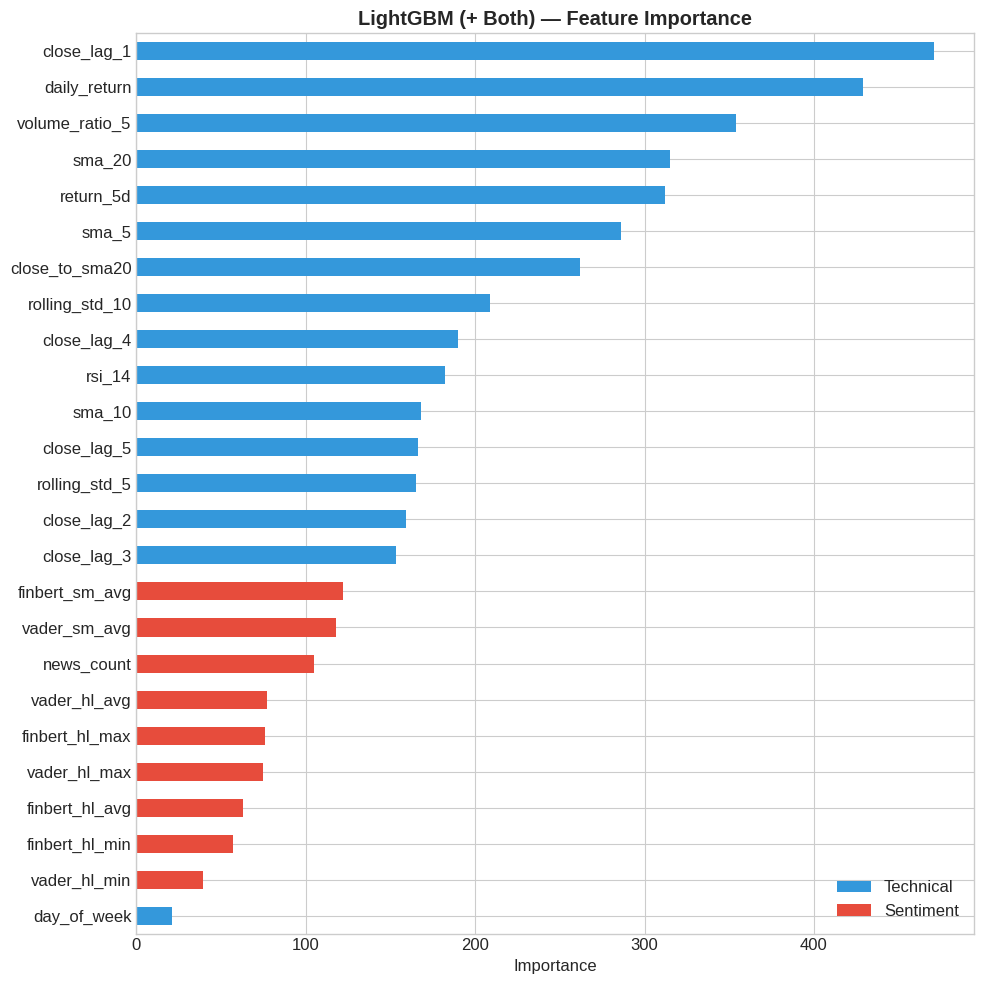

In [25]:
lgb_both_model, lgb_both_cols = models_dict['LightGBM (+ Both)']
importance = pd.Series(lgb_both_model.feature_importances_, index=lgb_both_cols).sort_values(ascending=True)

colors = ['#e74c3c' if f in all_sent_cols else '#3498db' for f in importance.index]
fig, ax = plt.subplots(figsize=(10, 10))
importance.plot(kind='barh', ax=ax, color=colors)
ax.set_title('LightGBM (+ Both) — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#3498db', label='Technical'), Patch(facecolor='#e74c3c', label='Sentiment')], loc='lower right')
plt.tight_layout()
plt.show()

Interesting to see how LightGBM presents the price features different from XGBoost with the addition of news sentiment. The first distributes importance across a broader mix of technical features, where the later heavily weight dominant lags.

# 6. Final remarks

1. **Ridge with news is the overall best model** (by a slight margin). Ridge with price only I would consider it the best option considering its a much simpler model.

2. **News sentiment** do improve the models in general but I would not consider it relevant for the prediction (or maybe my approach to include them is not the best). It matches what I observed in the EDA with the weak correlation between the two feature data sets.

3. **Model architecture was more important** than feature impact. The linear model outperforms due to the nature of the autocorrelated data.


**Limitations**

- Data set: 241 trading days limits non-linear models.
- Some tickers had more news items than others (AMZN: 941 - GOOGL: 386 leading to variable sentiment signal).